In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from PIL import ImageEnhance
import random
import re
from pathlib import Path

In [3]:
from pathlib import Path
import sys
import random
import re
import importlib

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

COMMON_DIR = BASE_DIR / 'synthetic_scenarios'
FRONT_DIR = COMMON_DIR / 'front'

candidate_project_dirs = [
    Path.cwd(),
    COMMON_DIR,
    FRONT_DIR,
]

candidate_project_dirs += [
    p.parent for p in Path('/content/drive').glob(
        '.shortcut-targets-by-id/*/*/synthetic_scenarios/front/shelf_synthetic_common.py'
    )
]

PROJECT_DIR = None
for d in candidate_project_dirs:
    if (d / 'shelf_synthetic_common.py').exists():
        PROJECT_DIR = d
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        'shelf_synthetic_common.py 파일을 찾지 못했습니다. '
        '노트북(.ipynb)과 shelf_synthetic_common.py를 같은 폴더에 두거나, '
        'PROJECT_DIR를 실제 파일 위치로 수정해주세요.'
    )

LABELER_DIR = COMMON_DIR

if not (LABELER_DIR / 'synthetic_label_exporter.py').exists():
    raise FileNotFoundError(
        f'synthetic_label_exporter.py 파일을 찾지 못했습니다: {LABELER_DIR}'
    )

# shelf_synthetic_common.py는 front 폴더에서,
# synthetic_label_exporter.py는 synthetic_scenarios 공통 폴더에서 import
for p in [PROJECT_DIR, LABELER_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print('공통 py 파일 위치:', PROJECT_DIR / 'shelf_synthetic_common.py')
print('라벨 exporter 위치:', LABELER_DIR / 'synthetic_label_exporter.py')
print('BASE_DIR:', BASE_DIR)

import shelf_synthetic_common as synth
import synthetic_label_exporter as labeler

importlib.reload(synth)
importlib.reload(labeler)

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_정면.png',
    seed=42,
)

print("shelf_lip_polygons 개수:", len(ctx.get("shelf_lip_polygons", [])))
print("context 생성 완료")

공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/front/shelf_synthetic_common.py
라벨 exporter 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
shelf_lip_polygons 개수: 5
context 생성 완료


In [4]:
def get_next_start_index(image_dir, scenario_code):
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)

        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1

In [5]:
def apply_random_lighting(image):
    """
    S7 조도 변화 적용 함수

    너무 어두우면 YOLO가 인식하기 어려우므로
    dark의 최저 밝기는 0.68로 제한한다.
    """

    lighting_mode = random.choice(["dark", "normal", "bright"])

    if lighting_mode == "dark":
        brightness_factor = random.uniform(0.68, 0.84)
        contrast_factor = random.uniform(0.90, 1.02)

    elif lighting_mode == "normal":
        brightness_factor = random.uniform(0.92, 1.06)
        contrast_factor = random.uniform(0.95, 1.05)

    elif lighting_mode == "bright":
        brightness_factor = random.uniform(1.08, 1.22)
        contrast_factor = random.uniform(0.96, 1.08)

    # 밝기 적용
    image = ImageEnhance.Brightness(image).enhance(brightness_factor)

    # 대비 적용
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)

    lighting_info = {
        "lighting_mode": lighting_mode,
        "brightness_factor": round(brightness_factor, 4),
        "contrast_factor": round(contrast_factor, 4),
    }

    return image, lighting_info

S7 정면 생성 중:   0%|          | 0/140 [00:00<?, ?img/s]

[20/140] 완료 | 최근 파일: synthetic_s7_020.png | 조도: normal | 밝기: 1.0145 | 대비: 0.9924 | ctx: 0.34초 | render: 22.67초 | label: 3.89초 | 평균: 28.04초/장 | 예상 남은 시간: 56.1분
[40/140] 완료 | 최근 파일: synthetic_s7_040.png | 조도: bright | 밝기: 1.1724 | 대비: 1.0472 | ctx: 0.34초 | render: 23.55초 | label: 3.84초 | 평균: 27.48초/장 | 예상 남은 시간: 45.8분
[60/140] 완료 | 최근 파일: synthetic_s7_060.png | 조도: normal | 밝기: 1.0078 | 대비: 1.0261 | ctx: 0.33초 | render: 24.03초 | label: 3.33초 | 평균: 27.31초/장 | 예상 남은 시간: 36.4분
[80/140] 완료 | 최근 파일: synthetic_s7_080.png | 조도: dark | 밝기: 0.7017 | 대비: 0.9625 | ctx: 0.33초 | render: 21.03초 | label: 3.08초 | 평균: 27.21초/장 | 예상 남은 시간: 27.2분
[100/140] 완료 | 최근 파일: synthetic_s7_100.png | 조도: normal | 밝기: 0.9537 | 대비: 1.047 | ctx: 0.33초 | render: 21.86초 | label: 4.0초 | 평균: 27.16초/장 | 예상 남은 시간: 18.1분
[120/140] 완료 | 최근 파일: synthetic_s7_120.png | 조도: bright | 밝기: 1.1656 | 대비: 1.0484 | ctx: 0.33초 | render: 21.89초 | label: 4.06초 | 평균: 27.12초/장 | 예상 남은 시간: 9.0분
[140/140] 완료 | 최근 파일: synthetic_s7_140.png | 조도: 

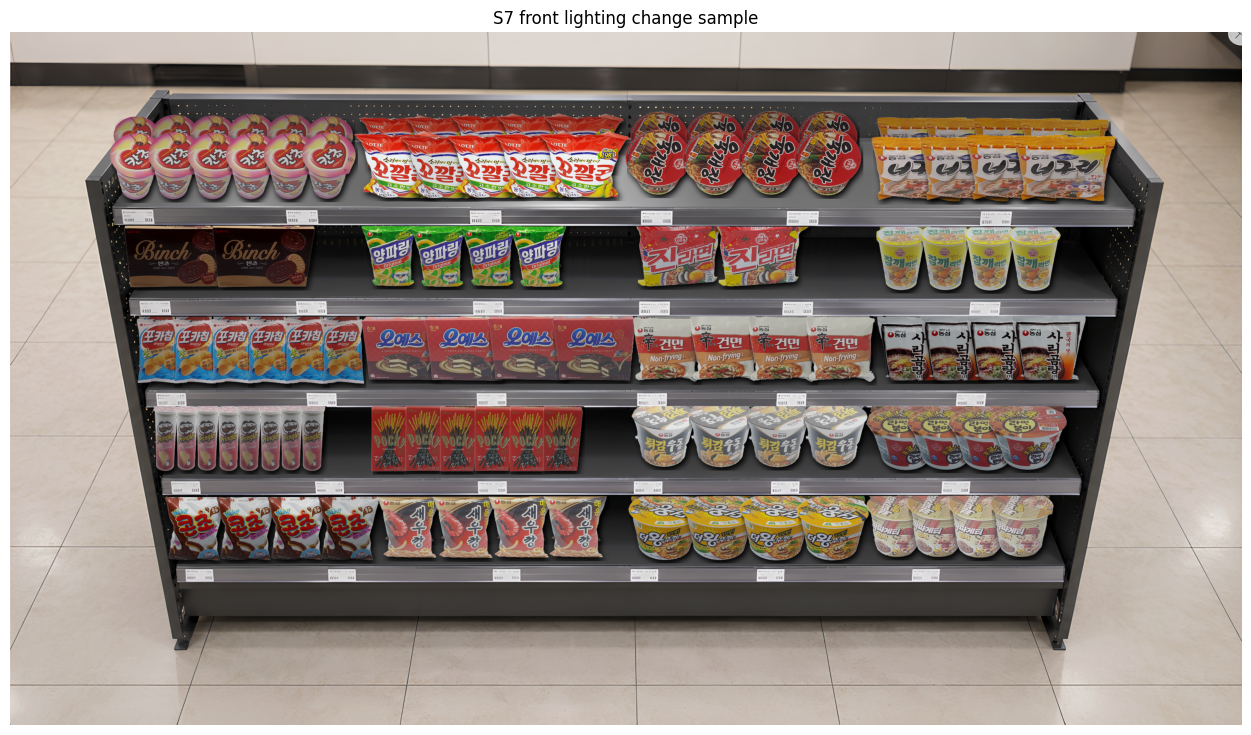

In [6]:
# ============================================================
# S7 정면 합성 + 이미지/라벨 저장
# 조도 변화 140장
# 랜덤 상품 배치 유지 버전: ctx를 루프 안에서 매번 생성
# ============================================================

from tqdm.auto import tqdm
import time
import random
import numpy as np

SCENARIO_CODE = 'S7'
SCENARIO_NAME = '조도 변화'

NUM_IMAGES = 140
BASE_SEED = 770770

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'front' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'front' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'front' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'front' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None
last_label_result = None

start_time = time.time()

pbar = tqdm(range(NUM_IMAGES), desc=f'{SCENARIO_CODE} 정면 생성 중', unit='img')

for image_idx in pbar:
    seed = BASE_SEED + image_idx

    random.seed(seed)
    np.random.seed(seed)

    if hasattr(synth, 'reset_random_seed'):
        synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 1. 이미지마다 context 새로 생성
    # 중요:
    # create_synthetic_context 안에서 상품이 slot에 랜덤 배치되므로
    # 상품/위치가 매번 바뀌려면 반드시 루프 안에 있어야 함
    # ------------------------------------------------------------
    t_ctx0 = time.time()

    ctx_i = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_정면.png',
        seed=seed,
    )

    t_ctx1 = time.time()

    # ------------------------------------------------------------
    # 2. S7은 정상 진열 slot_plan 생성
    # ------------------------------------------------------------
    slot_plan = synth.make_normal_slot_plan(ctx_i)

    for slot_id, target in slot_plan.items():
        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', 0)))

        target.update({
            'scenario_code': SCENARIO_CODE,
            'sub_scenario_code': SCENARIO_CODE,
            'scenario_name': SCENARIO_NAME,
            'action': 'lighting_change',
            'list_up': False,
            'final_status': '정상',

            'status_code': 'NORMAL',
            'status_label': '정상',

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'required_front_qty': front_qty,
            'required_back_qty': back_qty,
            'front_display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],

            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,

            'reduced_front_qty': front_qty,
            'target_column_index': None,

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

    # ------------------------------------------------------------
    # 3. 렌더링
    # ------------------------------------------------------------
    t_render0 = time.time()

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx_i,
        slot_plan=slot_plan,
        seed=seed
    )

    # ------------------------------------------------------------
    # 4. 조도 변화 적용
    # ------------------------------------------------------------
    result, lighting_info = apply_random_lighting(result)

    # slot_labels에도 lighting_info를 넣어두면 JSON에서 슬롯별로도 추적 가능
    for slot_label in slot_labels:
        if isinstance(slot_label, dict):
            slot_label['lighting_info'] = lighting_info

    t_render1 = time.time()

    # ------------------------------------------------------------
    # 5. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 6. 이미지 + SAHI 기준 라벨 3종 저장
    # ------------------------------------------------------------
    t_label0 = time.time()

    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx_i,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='front',
        settings_extra={
            'source_notebook': 'S7_정면시나리오_합성.ipynb',
            'label_structure': 'sahi_full_image',
            'scenario_rule': 'lighting change only',
            'ctx_reuse': False,
            'random_product_layout': True,
            'lighting_info': lighting_info,
        }
    )

    t_label1 = time.time()

    saved_paths.append(save_path)
    last_result = result
    last_label_result = label_result

    ctx_sec = round(t_ctx1 - t_ctx0, 2)
    render_sec = round(t_render1 - t_render0, 2)
    label_save_sec = round(t_label1 - t_label0, 2)
    total_sec = round(t_label1 - t_ctx0, 2)

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,
        'lighting_mode': lighting_info['lighting_mode'],
        'brightness_factor': lighting_info['brightness_factor'],
        'contrast_factor': lighting_info['contrast_factor'],
        'n_objects': len(objects),
        'n_slots': len(slot_labels),
        'ctx_sec': ctx_sec,
        'render_sec': render_sec,
        'label_save_sec': label_save_sec,
        'total_sec': total_sec,
        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0 or (image_idx + 1) == NUM_IMAGES:
        elapsed = time.time() - start_time
        avg_sec = elapsed / (image_idx + 1)
        remain_sec = avg_sec * (NUM_IMAGES - (image_idx + 1))

        print(
            f'[{image_idx + 1}/{NUM_IMAGES}] 완료 | '
            f'최근 파일: {save_name} | '
            f'조도: {lighting_info["lighting_mode"]} | '
            f'밝기: {lighting_info["brightness_factor"]} | '
            f'대비: {lighting_info["contrast_factor"]} | '
            f'ctx: {ctx_sec}초 | '
            f'render: {render_sec}초 | '
            f'label: {label_save_sec}초 | '
            f'평균: {avg_sec:.2f}초/장 | '
            f'예상 남은 시간: {remain_sec/60:.1f}분'
        )

total_time = time.time() - start_time

print('\nS7 정면 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print(f'총 소요 시간: {total_time/60:.2f}분')
print(f'평균 시간: {total_time / len(saved_paths):.2f}초/장')

print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('\n처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('\n마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} front lighting change sample')